# **Introduction**  

**Welcome** to the first installment of my *role-play series* as a **data expert in the iGaming industry**. All individuals and organizations mentioned in this series are *fictional* and created solely for this exercise. To avoid misinformation, I will not share this outside of this context.  

---

## **Churn Analysis and Predictive Modeling in iGaming**  

For my first article, I chose **churn analysis and predictive modeling**, a favorite topic in industries with *high customer turnover*. In any relationship, predicting the other party’s feelings is crucial. In this series, I worked with a *comprehensive iGaming dataset* to predict whether a customer: is about to leave, or has already disconnected from our services.  

### **Objective**  
The goal is to build a **predictive model** that can:  
1. Analyze user data.  
2. Determine the relationship status:  
   - ✅ **Intact**  
   - ⚠️ **Weakening**  
   - ❌ **Broken**  
3. Assess customer status in *real-time* or forecast *future churn risks*.  

---

## **Dataset Overview**  
The dataset includes the following key features:  

### **Core Identifiers**  
- `PlayerID`  
- `Churn` (*Target:* `Yes`/`No`)  

### **Financial Activity**  
- `MonthlyDeposits`  
- `MonthlyWagering`  
- `TotalBonusTaken`  
- `OverageWagering`  

### **Engagement & Support**  
- `VIPConciergeContacts`  
- `CustomerCareCalls`  
- `RetentionCallContacts`  

### **Behavioral Metrics**  
- `CrossBorderPlay`  
- `PeakTimePlay`  
- `OffPeakPlay`  
- `ActiveDays`  

### **Technical & Transactional**  
- `FailedTransactions`  
- `PendingPayouts`  
- `GameSessionRedirects`  

### **Demographics & Preferences**  
- `AgeOfCustomer`  
- `PlayerTier`  
- `GeoSegment`  
- `MaritalStatus`  

### **Risk & Loyalty Indicators**  
- `HighRiskBets`  
- `SOI` (*Statement of Intent*)  
- `SOW` (*Scope of Work*)  
- `OptOutPromotions`  

import library

In [241]:
import numpy as np
import pylab as pl
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns
from sklearn.utils import shuffle
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.model_selection import cross_val_score, GridSearchCV
# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory



# Any results you write to the current directory are saved as output.

read dataset

In [242]:
train = pd.read_csv("C:/Users/Memre/VIPuserdatatrain.csv")
test = pd.read_csv("C:/Users/Memre/VIPuserdata.csv")

In [243]:
train.info()
train[0:10]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyDeposits            50891 non-null  float64
 3   MonthlyWagering            50891 non-null  float64
 4   TotalBonusTaken            50891 non-null  float64
 5   VIPConciergeContacts       50891 non-null  float64
 6   OverageWagering            50891 non-null  float64
 7   CrossBorderPlay            50891 non-null  float64
 8   PercChangeWagering         50680 non-null  float64
 9   PercChangeDeposits         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

,PlayerID,Churn,MonthlyDeposits,MonthlyWagering,TotalBonusTaken,VIPConciergeContacts,OverageWagering,CrossBorderPlay,PercChangeWagering,PercChangeDeposits,...,ReferralsGenerated,PlayerTier,HighRiskCasino,CreditAdjustments,AvgBetSize,ContactedRetention,UserPotentialTier,GeoSegment,EmploymentStatus,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes
5,3000030,No,38.05,682.0,52.0,0.25,0.0,0.0,148.0,-3.1,...,0,1,No,1,30,No,3-Good,Other,Other,Yes
6,3000038,No,31.66,26.0,30.0,0.25,0.0,0.0,60.0,4.0,...,0,9,No,1,30,No,1-Highest,Other,Self,Yes
7,3000042,No,62.13,98.0,66.0,2.48,0.0,0.0,24.0,6.8,...,0,6,No,0,30,No,1-Highest,Other,Professional,No
8,3000046,No,35.30,24.0,35.0,0.00,0.0,0.0,20.0,-0.3,...,0,9,No,0,80,No,1-Highest,Other,Other,Yes
9,3000050,No,81.00,1056.0,75.0,0.00,0.0,0.0,43.0,2.4,...,0,5,No,1,30,No,3-Good,Other,Professional,No


In [244]:
#Churn : Yes:1 , No:0
Churn = {'Yes': 1,'No': 0} 
  
# traversing through dataframe 
# values where key matches 
train.Churn = [Churn[item] for item in train.Churn] 
print(train)

       PlayerID  Churn  MonthlyDeposits  MonthlyWagering  TotalBonusTaken  \
0       3000002      1            24.00            219.0             22.0   
1       3000010      1            16.99             10.0             17.0   
2       3000014      0            38.00              8.0             38.0   
3       3000022      0            82.28           1312.0             75.0   
4       3000026      1            17.14              0.0             17.0   
...         ...    ...              ...              ...              ...   
51042   3399958      1              NaN              NaN              NaN   
51043   3399974      0            95.17           1745.0             85.0   
51044   3399978      1              NaN              NaN              NaN   
51045   3399990      0              NaN              NaN              NaN   
51046   3399994      0              NaN              NaN              NaN   

       VIPConciergeContacts  OverageWagering  CrossBorderPlay  \
0         

# Handling missing data

In [245]:
print("Any missing sample in training set:",train.isnull().values.any())
print("Any missing sample in test set:",test.isnull().values.any(), "\n")

Any missing sample in training set: True
Any missing sample in test set: True 



We replaced all missing values with zeros for simplicity in this POC. While other methods like imputation exist, this approach keeps things straightforward.

In [246]:
# for column
#train['MonthlyRevenue'].fillna((train['MonthlyRevenue'].median()), inplace=True)
# for column
train['MonthlyDeposits'] = train['MonthlyDeposits'].replace(np.nan, 0)

# for whole dataframe
train = train.replace(np.nan, 0)

# inplace
train.replace(np.nan, 0, inplace=True)



In [247]:
# for column
#train['MonthlyMinutes'].fillna((train['MonthlyMinutes'].median()), inplace=True)
train['MonthlyWagering'] = train['MonthlyWagering'].replace(np.nan, 0)

# for whole dataframe
train = train.replace(np.nan, 0)

# inplace
train.replace(np.nan, 0, inplace=True)

In [248]:
# for column
#train['TotalRecurringCharge'].fillna((train['TotalRecurringCharge'].median()), inplace=True)
train['TotalBonusTaken'] = train['TotalBonusTaken'].replace(np.nan, 0)

# for whole dataframe
train = train.replace(np.nan, 0)

# inplace
train.replace(np.nan, 0, inplace=True)


In [249]:
# for column
#train['DirectorAssistedCalls'].fillna((train['DirectorAssistedCalls'].median()), inplace=True)
train['VIPConciergeContacts'] = train['VIPConciergeContacts'].replace(np.nan, 0)

# for whole dataframe
train = train.replace(np.nan, 0)

# inplace
train.replace(np.nan, 0, inplace=True)

print(train)

       PlayerID  Churn  MonthlyDeposits  MonthlyWagering  TotalBonusTaken  \
0       3000002      1            24.00            219.0             22.0   
1       3000010      1            16.99             10.0             17.0   
2       3000014      0            38.00              8.0             38.0   
3       3000022      0            82.28           1312.0             75.0   
4       3000026      1            17.14              0.0             17.0   
...         ...    ...              ...              ...              ...   
51042   3399958      1             0.00              0.0              0.0   
51043   3399974      0            95.17           1745.0             85.0   
51044   3399978      1             0.00              0.0              0.0   
51045   3399990      0             0.00              0.0              0.0   
51046   3399994      0             0.00              0.0              0.0   

       VIPConciergeContacts  OverageWagering  CrossBorderPlay  \
0         

In [250]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
def FunLabelEncoder(df):
    for c in df.columns:
        if df.dtypes[c] == object:
            le.fit(df[c].astype(str))
            df[c] = le.transform(df[c].astype(str))
    return df

In [251]:
train = FunLabelEncoder(train)
train.info()
train.iloc[235:300,:]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   51047 non-null  int64  
 1   Churn                      51047 non-null  int64  
 2   MonthlyDeposits            51047 non-null  float64
 3   MonthlyWagering            51047 non-null  float64
 4   TotalBonusTaken            51047 non-null  float64
 5   VIPConciergeContacts       51047 non-null  float64
 6   OverageWagering            51047 non-null  float64
 7   CrossBorderPlay            51047 non-null  float64
 8   PercChangeWagering         51047 non-null  float64
 9   PercChangeDeposits         51047 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

,PlayerID,Churn,MonthlyDeposits,MonthlyWagering,TotalBonusTaken,VIPConciergeContacts,OverageWagering,CrossBorderPlay,PercChangeWagering,PercChangeDeposits,...,ReferralsGenerated,PlayerTier,HighRiskCasino,CreditAdjustments,AvgBetSize,ContactedRetention,UserPotentialTier,GeoSegment,EmploymentStatus,MaritalStatus
235,3001782,1,64.80,479.0,50.0,0.00,139.0,0.0,-337.0,-13.3,...,0,3,0,0,8,0,0,2,4,2
236,3001786,1,17.14,3.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,0,0,15,0,0,2,3,2
237,3001790,0,124.06,2955.0,82.0,0.00,421.0,0.0,262.0,20.0,...,0,0,0,1,14,0,0,2,3,1
238,3001794,0,80.28,1245.0,68.0,1.24,73.0,0.0,-160.0,-62.1,...,0,6,0,3,0,0,2,0,4,2
239,3001802,0,100.05,820.0,85.0,3.46,0.0,17.5,2.0,-16.1,...,0,8,0,0,0,0,0,0,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,3002250,1,95.30,894.0,52.0,2.48,30.0,28.4,146.0,-10.0,...,0,0,0,0,3,0,2,0,3,1
296,3002258,0,104.29,1005.0,105.0,0.99,2.0,3.7,-145.0,1.9,...,0,0,0,0,8,0,0,0,3,1
297,3002262,0,95.27,815.0,95.0,1.49,0.0,0.0,-350.0,-7.0,...,0,5,0,0,0,0,0,0,3,1
298,3002270,0,79.84,596.0,75.0,1.73,8.0,0.0,-38.0,-0.9,...,0,9,0,0,3,0,0,2,3,2


In [252]:
test = FunLabelEncoder(test)
test.info()
test.iloc[235:300,:]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   20000 non-null  int64  
 1   Churn                      0 non-null      float64
 2   MonthlyDeposits            19940 non-null  float64
 3   MonthlyWagering            19940 non-null  float64
 4   TotalBonusTaken            19940 non-null  float64
 5   VIPConciergeContacts       19940 non-null  float64
 6   OverageWagering            19940 non-null  float64
 7   CrossBorderPlay            19940 non-null  float64
 8   PercChangeWagering         19865 non-null  float64
 9   PercChangeDeposits         19865 non-null  float64
 10  DroppedCalls               20000 non-null  float64
 11  BlockedCalls               20000 non-null  float64
 12  UnansweredCalls            20000 non-null  float64
 13  CustomerCareCalls          20000 non-null  flo

,PlayerID,Churn,MonthlyDeposits,MonthlyWagering,TotalBonusTaken,VIPConciergeContacts,OverageWagering,CrossBorderPlay,PercChangeWagering,PercChangeDeposits,...,ReferralsGenerated,PlayerTier,HighRiskCasino,CreditAdjustments,AvgBetSize,ContactedRetention,UserPotentialTier,GeoSegment,EmploymentStatus,MaritalStatus
235,3004718,NaN,33.10,242.0,40.0,0.00,0.0,0.0,-110.0,-2.7,...,0,4,0,0,8,0,0,2,1,2
236,3004722,NaN,64.69,370.0,40.0,0.25,98.0,0.0,8.0,0.1,...,1,0,0,1,8,0,0,3,3,1
237,3004738,NaN,100.56,660.0,50.0,3.46,151.0,0.0,-390.0,-47.6,...,0,6,0,0,3,0,2,0,3,0
238,3004746,NaN,35.17,308.0,30.0,0.00,14.0,0.0,42.0,10.9,...,1,0,0,1,15,0,0,2,3,2
239,3004762,NaN,30.25,268.0,30.0,0.25,0.0,0.0,48.0,-0.2,...,0,6,0,0,3,0,0,2,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,3005682,NaN,81.49,741.0,75.0,5.69,0.0,0.8,185.0,-1.5,...,0,0,0,0,14,0,0,2,3,1
296,3005710,NaN,30.00,204.0,30.0,0.00,0.0,0.0,43.0,0.0,...,0,0,0,0,8,0,0,0,3,1
297,3005750,NaN,51.21,312.0,35.0,0.25,37.0,0.0,-149.0,-13.0,...,0,6,0,0,2,0,2,0,3,1
298,3005766,NaN,35.72,94.0,30.0,3.46,0.0,0.0,-40.0,-2.8,...,0,7,0,1,8,0,0,2,3,0


In [253]:
test = test.drop(columns=['Churn'],

                 axis=1)
test = test.dropna(how='any')
print(test.shape)

(19533, 57)


In [254]:
#Frequency distribution of classes"
train_outcome = pd.crosstab(index=train["Churn"],  # Make a crosstab
                              columns="count")      # Name the count column

train_outcome

col_0,count
Churn,
0,36336
1,14711


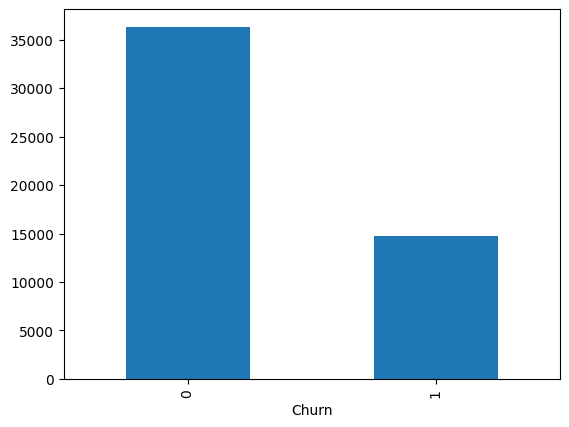

In [255]:
# Distribution of Churn
train.Churn.value_counts()[0:30].plot(kind='bar')
plt.show()

# Plotting Heatmap
A visual representation of data values using colors. Darker shades = stronger relationships. Helps spot key patterns at a glance.

<Axes: >

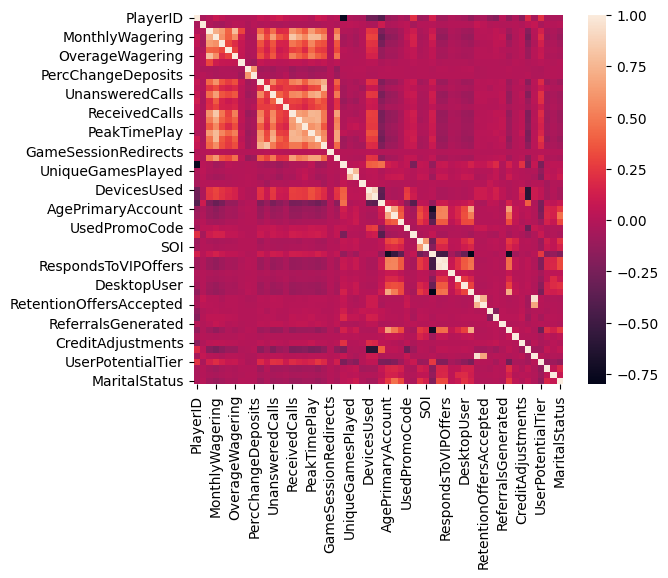

In [256]:
train = train[["PlayerID","Churn","MonthlyDeposits","MonthlyWagering","TotalBonusTaken","VIPConciergeContacts","OverageWagering","CrossBorderPlay","PercChangeWagering","PercChangeDeposits","DroppedCalls","BlockedCalls","UnansweredCalls","CustomerCareCalls","ThreewayCalls","ReceivedCalls","OutboundCalls","InboundCalls","PeakTimePlay","OffPeakPlay","FailedTransactions","GameSessionRedirects","PendingPayouts","MonthsActive","UniqueGamesPlayed","ActiveDays","GameCategoryPref","DevicesUsed","GameTitlesPlayed","DaysSinceLastDeviceChange","AgePrimaryAccount","AgeSecondaryUser","HouseholdSize","UsedPromoCode","MobileCapable","HighRiskBets","SOI","SOW","OfflineDepositUser","RespondsToVIPOffers","OptOutPromotions","IntlPlayFlag","DesktopUser","HasActivePaymentMethod","RetentionCallContacts","RetentionOffersAccepted","NewPlayerFlag","ExistingPlayerFlag","ReferralsGenerated","PlayerTier","HighRiskCasino","CreditAdjustments","AvgBetSize","ContactedRetention","UserPotentialTier","GeoSegment","EmploymentStatus","MaritalStatus"]] #Subsetting the data
cor = train.corr() #Calculate the correlation of the above variables
sns.heatmap(cor, square = True) #Plot the correlation as heat map

Here appear important variables (customer churn behavior):
1. TotalBonusTaken
1. RoamingCalls
1. DroppedCalls
1. CustomerCareCalls
1. OutboundCalls
1. FailedTransactions
1. PendingPayouts
1. ActiveDays
1. GameTitlesPlayed
1. AgePrimaryAccount
1. MobileCapable
1. SOI
1. OptOutPromotions
1. HasActivePaymentMethod
1. NewPlayerFlag
1. PlayerTier
1. AvgBetSize
1. GeoSegment

# SPLITING DATA

Data for training and testing
To select a set of training data that will be input in the Machine Learning algorithm, to ensure that the classification algorithm training can be generalized well to new data. For this study using a sample size of 30%, assumed it ideal ratio between training and testing

In [257]:
from sklearn.model_selection import train_test_split
Y = train['Churn']
X = train.drop(columns=['Churn'])
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=9)

In [258]:
print('X train shape: ', X_train.shape)
print('Y train shape: ', Y_train.shape)
print('X test shape: ', X_test.shape)
print('Y test shape: ', Y_test.shape)

X train shape:  (35732, 57)
Y train shape:  (35732,)
X test shape:  (15315, 57)
Y test shape:  (15315,)



# **Random Forest for Churn Prediction**  

We're using Random Forest to predict which iGaming players might churn. Here's why it's effective:  

## **How It Works**  
- Builds **100 decision trees**, each analyzing players differently  
- Each tree examines:  
  ✓ Random subset of features (deposits, gameplay, etc.)  
  ✓ Different sample of player data  
- Combines all trees' votes for **more reliable predictions**  

## **Key Advantages**  
✔ **Handles real-world data**  
  - Robust to missing values  
  - Works with both numerical and categorical features  

✔ **Detects complex patterns**  
  - Identifies interactions between factors (e.g., declining deposits + increased support calls)  

✔ **Built-in validation**  
  - Uses out-of-bag samples to estimate accuracy during training  

In [259]:
from sklearn.ensemble import RandomForestClassifier

# We define the model
rfcla = RandomForestClassifier(n_estimators=100,random_state=9,n_jobs=-1)

# We train model
rfcla.fit(X_train, Y_train)

# We predict target values
Y_predict5 = rfcla.predict(X_test)

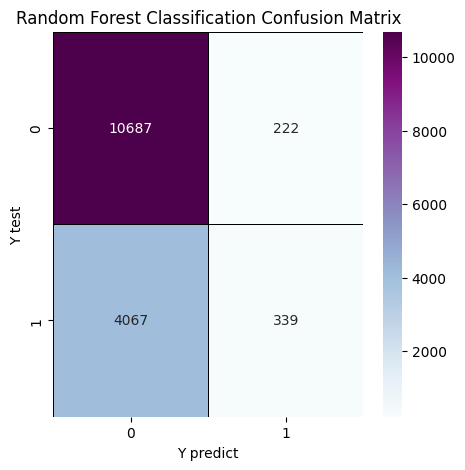

In [260]:
# The confusion matrix
rfcla_cm = confusion_matrix(Y_test, Y_predict5)
f, ax = plt.subplots(figsize=(5,5))
sns.heatmap(rfcla_cm, annot=True, linewidth=0.7, linecolor='black', fmt='g', ax=ax, cmap="BuPu")
plt.title('Random Forest Classification Confusion Matrix')
plt.xlabel('Y predict')
plt.ylabel('Y test')
plt.show()

In [261]:
# Test score
score_rfcla = rfcla.score(X_test, Y_test)
print(score_rfcla)

0.7199477636304277


## **2. Naive Bayes Classification**

### **Simple But Effective Probability**
We're using Gaussian Naive Bayes to estimate churn probability based on player behavior patterns. It works by:

- Calculating how likely churn is **given** observed features (deposits, gameplay, etc.)
- Assuming features affect churn **independently** (the "naive" part)
- Modeling numerical data with a bell curve (Gaussian) distribution

### **Why We Considered It**
✔ **Fast training/prediction** - Handles large datasets efficiently  
✔ **Works with incomplete data** - Makes reasonable estimates with missing info  
✔ **Probabilistic outputs** - Gives churn likelihood (0-100%) rather than just yes/no  

In [262]:
from sklearn.naive_bayes import GaussianNB

# We define the model
nbcla = GaussianNB()

# We train model
nbcla.fit(X_train, Y_train)

# We predict target values
Y_predict3 = nbcla.predict(X_test)

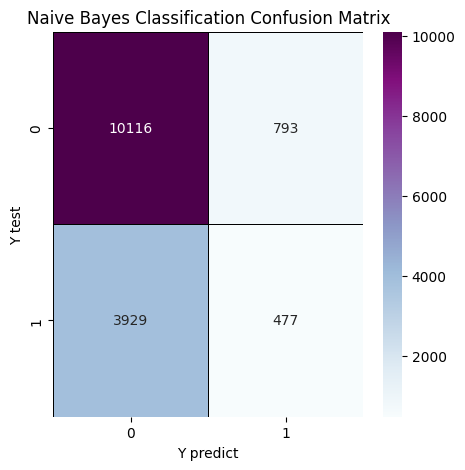

In [263]:
# The confusion matrix
nbcla_cm = confusion_matrix(Y_test, Y_predict3)
f, ax = plt.subplots(figsize=(5,5))
sns.heatmap(nbcla_cm, annot=True, linewidth=0.7, linecolor='black', fmt='g', ax=ax, cmap="BuPu")
plt.title('Naive Bayes Classification Confusion Matrix')
plt.xlabel('Y predict')
plt.ylabel('Y test')
plt.show()

In [264]:
# Test score
score_nbcla = nbcla.score(X_test, Y_test)
print(score_nbcla)

0.6916748285994123


# Comparison of classification techniques

# Test score


In [265]:
Testscores = pd.Series([score_rfcla,score_nbcla, ], 
                        index=['Random Forest Score','Naive Bayes Score' ]) 
print(Testscores)

Random Forest Score    0.719948
Naive Bayes Score      0.691675
dtype: float64


# ROC Curve
is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied.

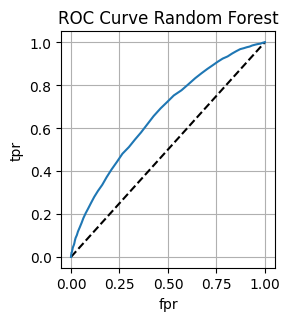

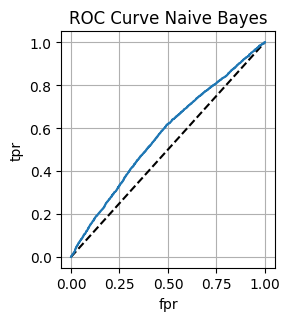

In [266]:
from sklearn.metrics import roc_curve
# Random Forest Classification
Y_predict5_proba = rfcla.predict_proba(X_test)
Y_predict5_proba = Y_predict5_proba[:, 1]
fpr, tpr, thresholds = roc_curve(Y_test, Y_predict5_proba)
plt.subplot(331)
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr, label='ANN')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('ROC Curve Random Forest')
plt.grid(True)
plt.subplots_adjust(top=2, bottom=0.08, left=0.10, right=1.4, hspace=0.45, wspace=0.45)
plt.show()

# Naive Bayes Classification
Y_predict3_proba = nbcla.predict_proba(X_test)
Y_predict3_proba = Y_predict3_proba[:, 1]
fpr, tpr, thresholds = roc_curve(Y_test, Y_predict3_proba)
plt.subplot(332)
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr, label='ANN')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('ROC Curve Naive Bayes')
plt.grid(True)
plt.subplots_adjust(top=2, bottom=0.08, left=0.10, right=1.4, hspace=0.45, wspace=0.45)
plt.show()

# Conclusion

## **Model Comparison & Practical Applications**

### **Why Random Forest Outperformed Naive Bayes**
- **Handles Complexity Better**:
  - RF captures interactions between features (e.g., how deposit patterns + customer service calls combine to predict churn)
  - Naive Bayes assumes all features act independently (often too simplistic for real-world behavior)

- **More Robust with Real Data**:
  - Works well with both categorical (player tier) and numerical (deposit amounts) features
  - Naturally handles missing values and outliers
  - Provides feature importance scores (shows which factors matter most)

### **What This Model Enables**

#### **1. Real-Time Relationship Scoring**  
Deploy as a web app where staff can:
- Input player ID or upload data
- Instantly see:
  - 🔴 **High Risk** (likely to churn)
  - 🟡 **Warning Signs** (needs attention)
  - 🟢 **Healthy** (stable relationship)

#### **2. Automated Monitoring**  
```python
# Sample prediction for new data
def predict_relationship(new_player_data):
    churn_prob = rf_model.predict_proba(new_player_data)[:,1]
    if churn_prob > 0.7:
        return "🔴 High Risk - Immediate action suggested"
    elif churn_prob > 0.4:
        return "🟡 Warning - Monitor closely"
    else:
        return "🟢 Healthy - Standard engagement"
```
### **3. Targeted Retention**  
Flag at-risk players for:  
-  **Personalized bonus offers** (tailored to player history)  
-  **VIP concierge outreach** (dedicated account manager contact)  
-  **Payment method updates** (reduce failed transactions)  

---

### **Next-Level Implementation**  
#### **API Integration**  
- Connect directly to your CRM to:  
  - Score all players daily  
  - Update churn risk in real-time  

#### **Automated Alerts**  
- Configure notifications for:  
  -  Email/Slack alerts when VIP players become high-risk  
  -  Real-time dashboards for customer support teams  

#### **Root Cause Analysis**  
- Use feature importance to:  
  - Identify operational pain points (e.g., failed transactions = 23% of churn)  
  - Prioritize product improvements  

> *"This isn't just academic - it's a working tool that turns data into retention strategies."*  